## Probelm statment
A leading retail company wants to better understand its customers’ shopping behavior in order 
to improve sales, customer satisfaction, and long-term loyalty. The management team has 
noticed changes in purchasing patterns across demographics, product categories, and sales 
channels (online vs. offline). They are particularly interested in uncovering which factors, such 
as discounts, reviews, seasons, or payment preferences, drive consumer decisions and repeat 
purchases. 
You are tasked with analyzing the company’s consumer behavior dataset to answer the 
following overarching business question: 
“How can the company leverage consumer shopping data to identify trends, improve 
customer engagement, and optimize marketing and product strategies?”

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sakshi\Downloads\customer_shopping_behavior (1).csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
df.describe(include ='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [7]:
#median is robust to outlier
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [8]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [9]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [36]:
# Total sale renvenu
print(df["Purchase Amount (USD)"].sum())

233081


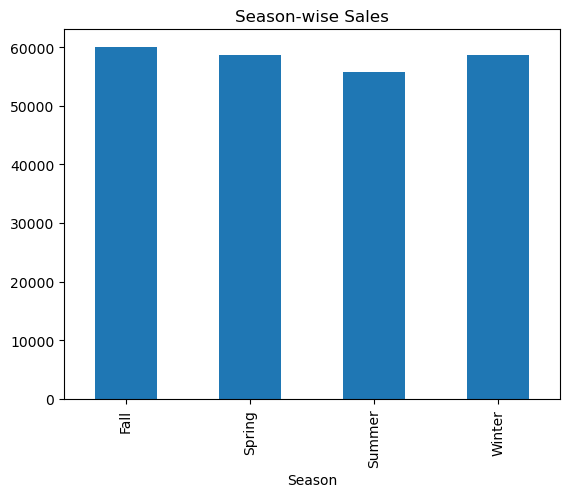

In [37]:
# Sales accoringing to season
season = df.groupby("Season")["Purchase Amount (USD)"].sum()

season.plot(kind="bar")
plt.title("Season-wise Sales")
plt.show()

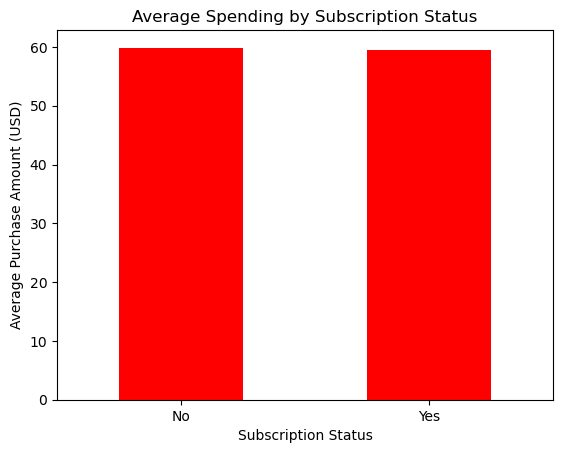

In [39]:
#  do Subscription customer pay more 
import matplotlib.pyplot as plt

subscription = df.groupby("Subscription Status")["Purchase Amount (USD)"].mean()

subscription.plot(kind="bar", color="red")

plt.title("Average Spending by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.show()

Customer Analysis

In [10]:
# unique customer
unique_customers = df["Customer ID"].nunique()

print("Total Unique Customers:", unique_customers)

Total Unique Customers: 3900


In [40]:
# Frquency mpping according to purchase day
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Quarterly': 90,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['Frequency of Purchases'].map(frequency_mapping)

In [41]:
df[['purchase_frequency_days','Frequency of Purchases']].head(10)

,purchase_frequency_days,Frequency of Purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


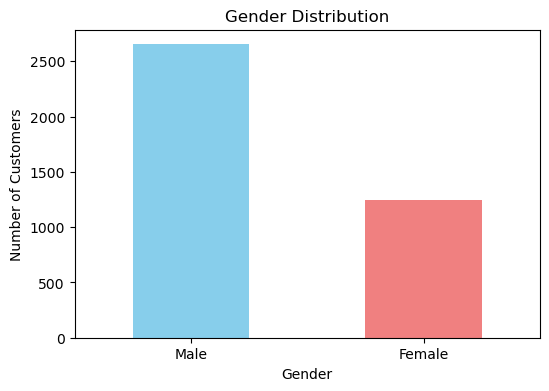

In [12]:
# Gender distribution of customer
import matplotlib.pyplot as plt

gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,4))
gender_counts.plot(
    kind="bar",
    color=["skyblue", "lightcoral"]   # Different colors for each bar
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [16]:
print(df.columns)

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')


In [18]:
# Age 
age_category_spending = (
    df.groupby(['Age','Category'])['Purchase Amount (USD)'].sum()
    .reset_index()
    .sort_values(by=["Age",'Purchase Amount (USD)'],ascending =[True,False])
)
print(age_category_spending)

     Age     Category  Purchase Amount (USD)
1     18     Clothing                   1993
0     18  Accessories                   1033
2     18     Footwear                    558
3     18    Outerwear                    555
5     19     Clothing                   2204
..   ...          ...                    ...
207   69    Outerwear                    306
209   70     Clothing                   1521
208   70  Accessories                   1473
210   70     Footwear                    628
211   70    Outerwear                    188

[212 rows x 3 columns]


. Sales by Shipping Type

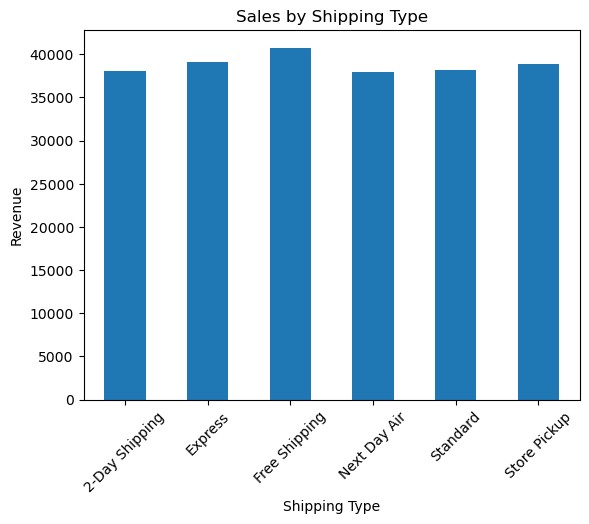

In [25]:
shipping = df.groupby("Shipping Type")["Purchase Amount (USD)"].sum()

shipping.plot(kind="bar")
plt.title("Sales by Shipping Type")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

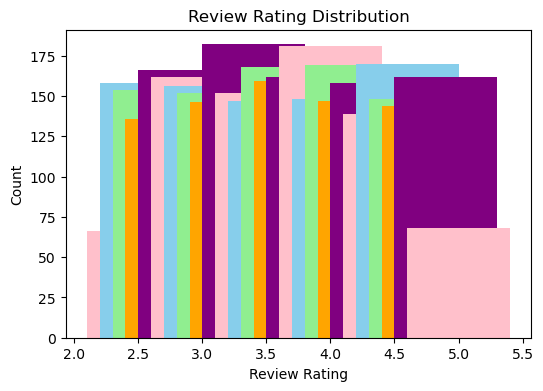

In [32]:
# Rating of product
import matplotlib.pyplot as plt

rating_counts = df["Review Rating"].value_counts().sort_index()

colors = ["pink", "skyblue", "lightgreen", "orange", "purple"]

plt.figure(figsize=(6,4))
plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.title("Review Rating Distribution")
plt.xlabel("Review Rating")
plt.ylabel("Count")
plt.show()

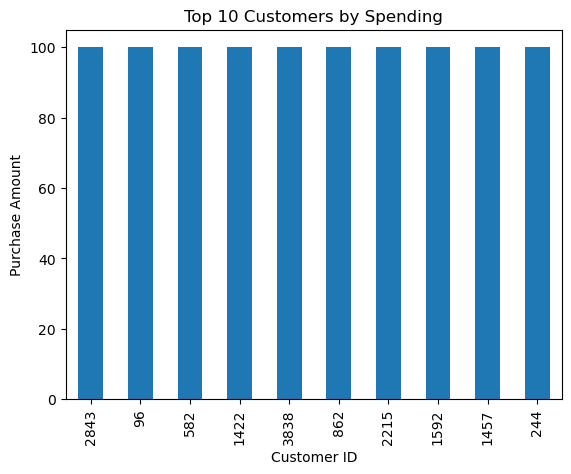

In [35]:
#     top 10 customer
top = df.groupby("Customer ID")["Purchase Amount (USD)"].sum().sort_values(ascending=False).head(10)

top.plot(kind="bar")
plt.title("Top 10 Customers by Spending")
plt.ylabel("Purchase Amount")
plt.show()